<a href="https://colab.research.google.com/github/AjayArmugam/Brain_Tumor/blob/main/Brain_Tumor_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
os.listdir('/content/drive/MyDrive/dataset_brain')

['brain_tumor_dataset.zip']

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/dataset_brain/brain_tumor_dataset.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    print("Folders:", dirs)
    print("Files:", len(files))
    print()

/content/dataset
Folders: ['Training', 'Testing']
Files: 0

/content/dataset/Training
Folders: ['pituitary', 'glioma', 'notumor', 'meningioma']
Files: 0

/content/dataset/Training/pituitary
Folders: []
Files: 1400

/content/dataset/Training/glioma
Folders: []
Files: 1400

/content/dataset/Training/notumor
Folders: []
Files: 1400

/content/dataset/Training/meningioma
Folders: []
Files: 1400

/content/dataset/Testing
Folders: ['pituitary', 'glioma', 'notumor', 'meningioma']
Files: 0

/content/dataset/Testing/pituitary
Folders: []
Files: 400

/content/dataset/Testing/glioma
Folders: []
Files: 400

/content/dataset/Testing/notumor
Folders: []
Files: 400

/content/dataset/Testing/meningioma
Folders: []
Files: 400



In [ ]:
import tensorflow as tf

train_path = "/content/dataset/Training"
test_path = "/content/dataset/Testing"

img_size = (224,224)
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_dataset.class_names
print("Classes:", class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


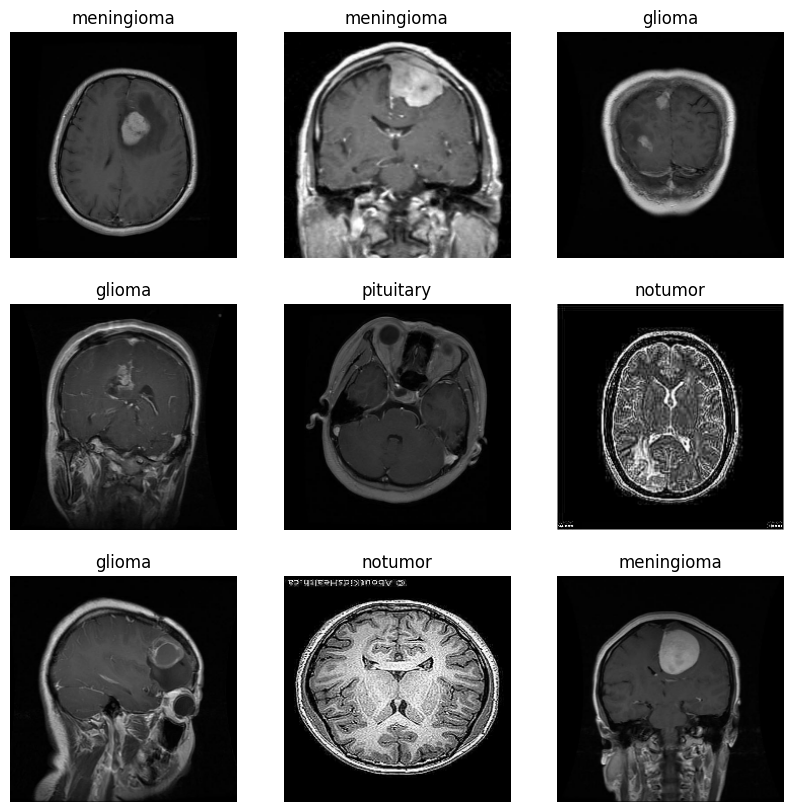

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [ ]:
normalization_layer = tf.keras.layers.Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(4,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

In [ ]:
import tensorflow as tf

train_path = "/content/dataset/Training"
test_path = "/content/dataset/Testing"

img_size = (224,224)
batch_size = 32

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    train_path,
    image_size=img_size,
    batch_size=batch_size
)

test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_dataset.class_names
print(class_names)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.
['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
from tensorflow.keras.applications.efficientnet import preprocess_input

train_dataset = train_dataset.map(lambda x, y: (preprocess_input(x), y))
test_dataset = test_dataset.map(lambda x, y: (preprocess_input(x), y))

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=10
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 104ms/step - accuracy: 0.7286 - loss: 0.8805 - val_accuracy: 0.8675 - val_loss: 0.4230
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 57ms/step - accuracy: 0.8863 - loss: 0.3135 - val_accuracy: 0.8750 - val_loss: 0.4374
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9057 - loss: 0.2550 - val_accuracy: 0.8906 - val_loss: 0.4328
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.9207 - loss: 0.2067 - val_accuracy: 0.9100 - val_loss: 0.4259
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - accuracy: 0.9252 - loss: 0.1901 - val_accuracy: 0.9119 - val_loss: 0.4376
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9405 - loss: 0.1560 - val_accuracy: 0.9181 - val_loss: 0.4753
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.9389 - loss: 0.1649 - val_accuracy: 0.9219 - val_loss: 0.4305
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 68ms/step - accuracy: 0.9455 - loss: 0.1496 -

In [ ]:
test_loss, test_acc = model.evaluate(test_dataset)

print(f"Test Accuracy: {test_acc*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9180 - loss: 0.5048
Test Accuracy: 92.31%
Test Loss: 0.5268


In [ ]:
model.save('/content/drive/MyDrive/brain_tumor_model.h5')